**This notebook shows how to create a GlacierMIP4 submission with per glacier (RGI7G) data. This is optional, as data can also be submitted as regional aggregates. In this example, we use data from an OGGM projection**.

First, we download OGGMs RGI7G projections, e.g. like this:
wget -c -nc -r -np -nH --cut-dirs=7 -A "*.nc" https://cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/oggm_v16/2025.6/w5e5/regional_spinup/CMIP6/2100/RGI2000-v7.0-G-01

Similar to the previous notebook for a regional OGGM submission, we start with inspecting the OGGM output files.

In [1]:
import xarray as xr

OGGM_data_folder = "oggm_data/2100/RGI2000-v7.0-G-01"

example_file_name = "run_hydro_w5e5_gcm_merged_MRI-ESM2-0_ssp119_bc_2000_2019_endyr2101_Batch_0_1000.nc"
ds = xr.load_dataset(OGGM_data_folder + "/" + example_file_name)
ds

<xarray.Dataset> Size: 47MB
Dimensions:                       (time: 102, rgi_id: 1000, month_2d: 12)
Coordinates:
  * time                          (time) float64 816B 2e+03 ... 2.101e+03
    hydro_year                    (time) int64 816B 2000 2001 2002 ... 2100 2101
    hydro_month                   (time) int64 816B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 816B 2000 2001 2002 ... 2100 2101
    calendar_month                (time) int64 816B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * rgi_id                        (rgi_id) <U23 92kB 'RGI2000-v7.0-G-01-00001...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/29)
    volume                        (time, rgi_id) float32 408kB 7.519e+06 ... 0.0
    volume_bsl                    (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float32 408kB 2.511e+05 ... 0.0
    length                        (time, rgi_id) float32 408kB 646.0 ... 0.0
    calving                       (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    ...                            ...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float32 5MB 7.548e...
    snow_bucket_monthly           (time, month_2d, rgi_id) float32 5MB 0.0 .....
    residual_mb_monthly           (time, month_2d, rgi_id) float32 5MB 0.0 .....
    water_level                   (rgi_id) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
    glen_a                        (rgi_id) float32 4kB 7.515e-24 ... 7.515e-24
    fs                            (rgi_id) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.3.dev30+gbba6e5f24
    calendar:       365-day no leap
    creation_date:  2025-12-17 10:50:06

We see that it contains the RGI7G ID as an axis. The same structure is required for the GlacierMIP4 output with indiv glaciers.

Again, similar to the previous notebook for regional submissions, we load OGGMs batch data into one dataset.

In [2]:
from pathlib import Path
files = sorted(Path(OGGM_data_folder).glob("*.nc"))

ds_mf = xr.open_mfdataset(
    files,
    combine="by_coords",
)

ds_mf

<xarray.Dataset> Size: 1GB
Dimensions:                       (time: 102, rgi_id: 27509, month_2d: 12)
Coordinates:
  * time                          (time) float64 816B 2e+03 ... 2.101e+03
    hydro_year                    (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    hydro_month                   (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_year                 (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_month                (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
  * rgi_id                        (rgi_id) <U23 3MB 'RGI2000-v7.0-G-01-00001'...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B dask.array<chunksize=(12,), meta=np.ndarray>
Data variables: (12/29)
    volume                        (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    volume_bsl                    (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    volume_bwl                    (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    area                          (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    length                        (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    calving                       (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    ...                            ...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float32 135MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    snow_bucket_monthly           (time, month_2d, rgi_id) float32 135MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    residual_mb_monthly           (time, month_2d, rgi_id) float32 135MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    water_level                   (rgi_id) float32 110kB dask.array<chunksize=(1000,), meta=np.ndarray>
    glen_a                        (rgi_id) float32 110kB dask.array<chunksize=(1000,), meta=np.ndarray>
    fs                            (rgi_id) float32 110kB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.3.dev30+gbba6e5f24
    calendar:       365-day no leap
    creation_date:  2025-12-17 10:50:06

We create the GlacierMIP template. Note that it does not contain information about the Glacier ID yet.

In [3]:
from src.create_template import create_glaciermip_dataset

start_date="2025-01-01"
end_date="2100-01-01"

glaciermip_ds = create_glaciermip_dataset(
    frequency="annual",
    start_date=start_date,
    end_date=end_date,
    epoch_date="1850-01-01",
    variable_yml="variable_definitions.yml",
)

glaciermip_ds

<xarray.Dataset> Size: 2kB
Dimensions:      (time: 76, nv: 2)
Coordinates:
  * time         (time) int32 304B 63918 64283 64648 65013 ... 90581 90946 91311
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 608B 63552 63918 63918 ... 90946 90946 91311
    area         (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mass         (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mass_bsl     (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    frontal_abl  (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Now we add the axis for RGI7G IDs to the template, so we can have individual glacier submissions. We take the RGI ID Strings from the OGGM data.

In [22]:
import numpy as np

# Copy the axis from OGGM's output
rgiids = ds_mf["rgi_id"].values.astype("<U23")
ds_indiv = glaciermip_ds.expand_dims(rgiid=rgiids)
ds_indiv = ds_indiv.assign_coords(rgiid=("rgiid", np.asarray(rgiids, dtype="<U23")))

# Don't extend the timebounds
ds_indiv["time_bounds"] = ds_indiv["time_bounds"].isel(rgiid=0, drop=True)

ds_indiv

<xarray.Dataset> Size: 36MB
Dimensions:      (time: 76, nv: 2, rgiid: 27509)
Coordinates:
  * time         (time) int32 304B 63918 64283 64648 65013 ... 90581 90946 91311
  * nv           (nv) int8 2B 0 1
  * rgiid        (rgiid) <U23 3MB 'RGI2000-v7.0-G-01-00001' ... 'RGI2000-v7.0...
Data variables:
    time_bounds  (time, nv) int32 608B 63552 63918 63918 ... 90946 90946 91311
    area         (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    mass         (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    mass_bsl     (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    frontal_abl  (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

Nextup, we copy the data from the OGGM dataset into the the GlacierMIP dataset.

In [23]:
# Let's add mass first in OGGM's data
GLACIERMIP_ICE_DENSITY = 900  # kg m-3
ds_mf["mass"] = ds_mf["volume"] * GLACIERMIP_ICE_DENSITY
ds_mf["mass_bsl"] = ds_mf["volume_bsl"] * GLACIERMIP_ICE_DENSITY

# Then we need to crop it to the same time window as the GlacierMIP output
start_year = 2025
end_year = 2100
ds_oggm = ds_mf.sel(
    time=slice(start_year, end_year)
)

glaciermip_names_to_oggm_names = {"area":"area", "frontal_abl":"calving", "mass":"mass", "mass_bsl":"mass_bsl"}

# Then we iterate over the data variables and simply paste the data
for var_name, da in ds_indiv.data_vars.items():
    # Exlude time bounds
    if "bounds" in var_name:
        continue
    
    oggm_name = glaciermip_names_to_oggm_names[var_name]

    # We have to transpose here to match the order of dimensions
    ds_indiv[var_name].values = ds_oggm[oggm_name].values.transpose()
    
ds_indiv



<xarray.Dataset> Size: 36MB
Dimensions:      (time: 76, nv: 2, rgiid: 27509)
Coordinates:
  * time         (time) int32 304B 63918 64283 64648 65013 ... 90581 90946 91311
  * nv           (nv) int8 2B 0 1
  * rgiid        (rgiid) <U23 3MB 'RGI2000-v7.0-G-01-00001' ... 'RGI2000-v7.0...
Data variables:
    time_bounds  (time, nv) int32 608B 63552 63918 63918 ... 90946 90946 91311
    area         (rgiid, time) float32 8MB 1.501e+05 1.494e+05 ... 0.0 3.998e+04
    mass         (rgiid, time) float32 8MB 2.387e+09 2.253e+09 ... 0.0 1.012e+07
    mass_bsl     (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    frontal_abl  (rgiid, time) float32 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

Lets plot the mass evolution of a single glacier (RGI2000-v7.0-G-01-20000).

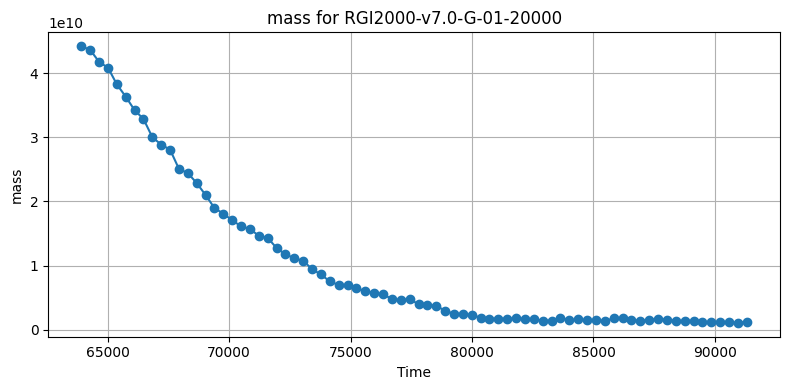

In [24]:
import matplotlib.pyplot as plt

var = "mass"
glacier_id = "RGI2000-v7.0-G-01-20000"

da = ds_indiv[var].sel(rgiid=glacier_id)

plt.figure(figsize=(8, 4))
plt.plot(da.time, da, marker="o")
plt.xlabel("Time")
plt.ylabel(var)
plt.title(f"{var} for {glacier_id}")
plt.grid(True)
plt.tight_layout()


And store the dataset as nc-file in examples folder.

In [25]:
import os 

GLACIER_MODEL = "OGGM"
RGI_REGION = "01indiv"
GCM = "MRI-ESM2-0"
SSP = "119"
FREQUENCY = "annual"

filename = GLACIER_MODEL + "_" + "rgi" + RGI_REGION + "_" + GCM + "_" + SSP + "_" + FREQUENCY + ".nc"

os.makedirs("examples", exist_ok=True)
ds_indiv.to_netcdf("examples/" + filename)